In [22]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message="The behavior of DataFrame concatenation")

# Is DISC+ Useful?

DISC+ is a plate dsicipline metric built from TrackMan pitch location data. What needs to be determined with any new statistic, though, is whether DISC+ is measuring something distinct, or if it is simply a rescaled version of stats that already exist.

I used PCA to check this in three ways:
1) Full PCA across DISC+, standard discipline stats, and a set of unrelated control stats related to power and quality of contact, in order to see which axis DISC+ loads on and whether it leaks into aces it shouldn't.
2) Redundancy check: PCA on the existing discipline stats only, to build an independent consensus discipline score and see how much of DISC+ it explains.
3) Communality check: how much of DISC+'s variance is tied to the dataset's shared structure at all, versus idiosyncratic structure.

### Setup

In [23]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

from data_prep import load_pitches, clean_pitches
from dataset import build_dataset

GAMES_DIR = "../input/gamedata"
MIN_PITCHES_SEEN = 200
DISC_COLS = ['Swing%', 'ZSwing%', 'OSwing%', 'Whiff%', 'Contact%', 'K%', 'BB%']
CONTROL_COLS = ['Hard%', 'BRL%']
N_COMPS = 4

In [24]:
# TEMPORARY WHILE TESTING...
import importlib

import data_prep
importlib.reload(data_prep)
from data_prep import load_pitches, clean_pitches

import dataset
importlib.reload(dataset)
from dataset import build_dataset

import discp
importlib.reload(discp)

<module 'discp' from '/Users/connorcourtright/Desktop/work/CornBelters/DISC+/discp.py'>

### Build the dataset
One row per qualified hitter (>= 200 pitches seen), with DISC+ and all companion stats. All stats are derived from the same TrackMan data used to calculate DISC+. The stats are stored to `pcainput.csv`.

In [25]:
import pathlib

if pathlib.Path("pcainput.csv").exists():
    df = pd.read_csv("pcainput.csv")
else:
    pitches = clean_pitches(load_pitches(GAMES_DIR))
    df = build_dataset(pitches)
    df.to_csv("pcainput.csv", index=False)

print(f"Loaded {len(df)} qualified hitters")
df.head()

Loaded 300 qualified hitters


,Batter,DISC+,Swing%,ZSwing%,OSwing%,Whiff%,Contact%,Hard%,BRL%,K%,BB%
0,Adam Kudronowicz,86.300153,0.436066,0.767568,0.291765,0.251880,0.748120,0.331658,0.030151,0.274194,0.161290
1,Adam Moser,75.397147,0.471338,0.714286,0.336634,0.385135,0.614865,0.208791,0.000000,0.432836,0.059701
2,Adison Worthman,94.191697,0.393414,0.748744,0.206349,0.339207,0.660793,0.406667,0.060000,0.336364,0.190909
3,Adrian Nina,198.931435,0.344186,0.720588,0.170068,0.148649,0.851351,0.222222,0.000000,0.148936,0.212766
4,Aiden McClary,68.261795,0.435644,0.750000,0.267477,0.186364,0.813636,0.234637,0.000000,0.123894,0.141593


### 1) Full PCA
In this step, the goal is to locate a component that loads heavily on the discipline stats and weakly on the control stats, referred to as the 'discipline axis'. A strong DISC+ loading there means that it is cleanly measuring disciple; a strong loading on the control axis would mean it is leaking power/contact skill into what is supposed to be a pure discipline number.

In [27]:
cols = ['DISC+'] + DISC_COLS + CONTROL_COLS
X = StandardScaler().fit_transform(df[cols])

pca_full = PCA()
pca_full.fit(X)

loadings_full = pd.DataFrame(
    pca_full.components_.T, index=cols, columns=[f"PC{i+1}" for i in range(len(cols))]
)

print("Explained variance ratio by component:")
for i, ev in enumerate(pca_full.explained_variance_ratio_[:N_COMPS]):
    print(f"\tPC{i+1}: {ev:0.3f}")

loadings_full.iloc[:, :N_COMPS].round(3)

Explained variance ratio by component:
	PC1: 0.388
	PC2: 0.282
	PC3: 0.142
	PC4: 0.070


,PC1,PC2,PC3,PC4
DISC+,-0.445,0.071,0.076,-0.019
Swing%,0.476,-0.165,-0.048,0.088
ZSwing%,0.351,-0.188,0.021,0.657
OSwing%,0.461,-0.096,-0.064,-0.197
Whiff%,0.201,0.537,-0.025,0.021
Contact%,-0.201,-0.537,0.025,-0.021
K%,0.077,0.543,-0.172,-0.080
BB%,-0.362,0.161,0.077,0.579
Hard%,0.056,-0.018,0.731,-0.334
BRL%,0.139,0.164,0.644,0.259


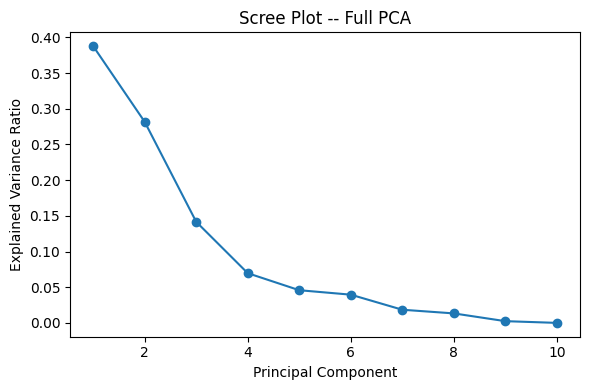

In [28]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), pca_full.explained_variance_ratio_, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot -- Full PCA")
plt.tight_layout()
plt.show()

### 2) Redundancy check
This involves performing PCA on the existing discipline stats only. By excluding DISC+ entirely, PC1 represents a consensus discipline score built purely from stats that already exist and are accepted as useful. Then, correlate DISC+ against that consensus PC1, and regress DISC+ on the top few consensus PCs to see how much of its variance they explain.

A high correlation number would mean that DISC+ is largely redundant with existing stats.

In [29]:
X_disc = StandardScaler().fit_transform(df[DISC_COLS])

pca_consensus = PCA()
pcs = pca_consensus.fit_transform(X_disc)

loadings_consensus = pd.DataFrame(
    pca_consensus.components_.T, index=DISC_COLS, columns=[f"PC{i+1}" for i in range(len(DISC_COLS))]
)

print("Explained variance ratio by component:")
for i, ev in enumerate(pca_consensus.explained_variance_ratio_[:N_COMPS]):
    print(f"  PC{i+1}: {ev:.3f}")

loadings_consensus.iloc[:, :N_COMPS].round(3)

Explained variance ratio by component:
  PC1: 0.444
  PC2: 0.392
  PC3: 0.094
  PC4: 0.044


,PC1,PC2,PC3,PC4
Swing%,0.512,-0.237,0.102,0.150
ZSwing%,0.373,-0.250,0.726,-0.389
OSwing%,0.495,-0.161,-0.214,0.637
Whiff%,0.289,0.509,0.086,0.052
Contact%,-0.289,-0.509,-0.086,-0.052
K%,0.159,0.539,-0.094,-0.258
BB%,-0.401,0.215,0.627,0.590


In [30]:
pc1 = pcs[:, 0]
disc_plus = df['DISC+'].values
corr_pc1 = np.corrcoef(pc1, disc_plus)[0, 1]

n_top = min(3, pcs.shape[1])
reg = LinearRegression().fit(pcs[:, :n_top], disc_plus)
r2 = reg.score(pcs[:, :n_top], disc_plus)

print(f"Correlation(DISC+, consensus PC1): {corr_pc1:.3f}")
print(f"R^2 of DISC+ ~ top {n_top} consensus PCs: {r2:.3f}")
print(f"Unexplained residual variance: {1 - r2:.3f}")

Correlation(DISC+, consensus PC1): -0.790
R^2 of DISC+ ~ top 3 consensus PCs: 0.666
Unexplained residual variance: 0.334


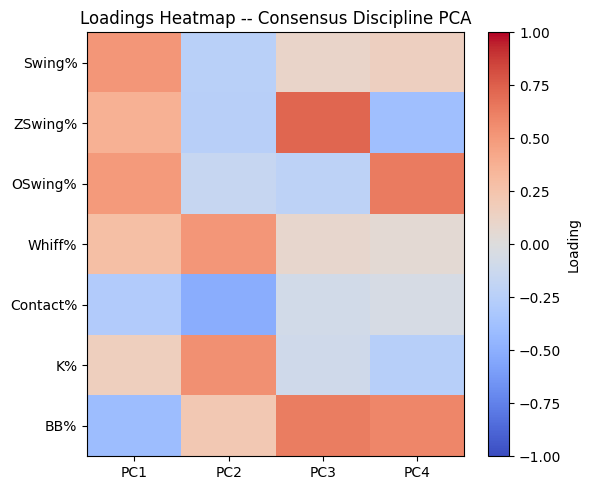

In [31]:
plt.figure(figsize=(6, 5))
plt.imshow(loadings_consensus.iloc[:, :N_COMPS].values, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Loading")
plt.xticks(range(N_COMPS), [f"PC{i+1}" for i in range(N_COMPS)])
plt.yticks(range(len(DISC_COLS)), DISC_COLS)
plt.title("Loadings Heatmap -- Consensus Discipline PCA")
plt.tight_layout()
plt.show()

### 3) Communality check
Now to examine how much of DISC+'s variance is explained by the retained components (eigenvalue > 1) in the full set of stats. High communality means DISC+'s variance aligns with the main shared axes of variation in the data; low communality is a sign that a lot of it may be noise.

In [32]:
cols_all = DISC_COLS + CONTROL_COLS + ['DISC+']
X_all = StandardScaler().fit_transform(df[cols_all])

pca_comm = PCA()
pca_comm.fit(X_all)

n_retain = max(int(np.sum(pca_comm.explained_variance_ > 1)), 1)
loadings_all = pca_comm.components_.T
disc_idx = cols_all.index('DISC+')
communality = np.sum(loadings_all[disc_idx, :n_retain] ** 2)

print(f"Components retained (eigenvalue > 1): {n_retain}")
print(f"DISC+ communality: {communality:.3f}")

Components retained (eigenvalue > 1): 3
DISC+ communality: 0.208


### Takeaways
- DISC+ loads only 0.071 on PC2 (the Whiff%/Contact%/K% axis) and 0.076 (Hard%/Barrel% axis) - both small, and neither close to the loadings the stats that actually define those components carry. DISC+, then, is clearly decontaminated from both bat-to-ball skill and power.

- DISC+ is concentrated on the swing-frequency axis, not independent of it. DISC+ loads on PC1 at -0.445, and PC1 is the dominant component at 38.8% of total variance. PC1 itself is a swing-frequency axis, with BB% loading -0.362 in the same direction as DISC+. This is directionally sensible, but also means that DISC+ sits on the exact same axis those existing stats already occupy rather than carving out independent space.

- Correlating DISC+ against a 'consensus' PC1 built from the existing discipline stats alone gives a correlation of -0.790, and regressing DISC+ on the top three consensus PCs gives an R^2 of 0.666. That means that about two-thirds of DISC+'s variance is explained by the existing toolkit combined. This is a strong redundancy signal.

Net read: DISC+ is cleanly separated from power and contact-quality metrics, but is somewhat redundant with the existing swing-frequency toolkit.